# **Exploratory Data Analysis: Historical Performance of National Football Teams**
**Project:** FIFA World Cup 2026 — Prediction & Simulation Engine  
**Author:** Gabriel Carrizo  
**Objective:** This notebook performs data cleaning, feature engineering, and descriptive analysis of international football results from 1872 to present, aiming to build a robust performance baseline for national teams.

## **Table of Contents**
* **Unit 1: Setup & Data Loading**
    * 1.1 Library Imports
    * 1.2 Dataset Loading (Historical Results, Team Info, 2026 Fixture)
* **Unit 2: Data Cleaning & Preprocessing**
    * 2.1 Data Type Formatting (Dates & Scores)
    * 2.2 Name Normalization (Legacy Entities & String Cleaning)
    * 2.3 Tournament Filtering (Official vs. Friendly Matches)
* **Unit 3: Feature Engineering**
    * 3.1 Outcome Calculation (Win/Loss/Draw)
    * 3.2 Performance Metrics Consolidation by Team (The `df_final_stats` Object)
* **Unit 4: Visual Exploratory Data Analysis (EDA)**
    * 4.1 Global Goal Distributions
    * 4.2 Group-by-Group Performance Comparison (2026 Groups A-L)
* **Unit 5: Insights & Future Work**
    * 5.1 Key Findings & Statistical Anomalies
    * 5.2 Next Steps: Exporting Clean Data for ML Modeling

## **Unit 1: Setup & Data Loading**
###  1.1 Library Imports
    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 1.2 Dataset Loading (Historical Results, Team Info, 2026 Fixture)

In [2]:
df_intl_results = pd.read_csv('../data/raw/results.csv')
fnames = pd.read_csv('../data/raw/former_names.csv')

# matches = pd.read_csv('../data/raw/matches.csv')
df_teams = pd.read_csv('../data/raw/teams.csv')

##  **Unit 2: Data Cleaning & Preprocessing**
###      2.1 Data Type Formatting (Dates & Scores)

In [3]:

df_intl_results['date'] = pd.to_datetime(df_intl_results['date'], format='mixed')

df_intl_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df_intl_results.describe()

,date,home_score,away_score
count,49353,49281.000000,49281.000000
mean,1994-04-24 02:01:40.224910336,1.757371,1.182444
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-08-21 00:00:00,1.000000,0.000000
50%,2000-06-25 00:00:00,1.000000,1.000000
75%,2013-06-12 00:00:00,2.000000,2.000000
max,2026-06-27 00:00:00,31.000000,21.000000
std,NaN,1.774995,1.402996


In [5]:
df_intl_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49353 entries, 0 to 49352
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49353 non-null  datetime64[ns]
 1   home_team   49353 non-null  object        
 2   away_team   49353 non-null  object        
 3   home_score  49281 non-null  float64       
 4   away_score  49281 non-null  float64       
 5   tournament  49353 non-null  object        
 6   city        49353 non-null  object        
 7   country     49353 non-null  object        
 8   neutral     49353 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB


There are missing some results.

In [6]:
df_intl_results[df_intl_results['home_score'].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49281,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49282,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49283,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49284,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49285,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
...,...,...,...,...,...,...,...,...,...
49348,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49349,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49350,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49351,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


We can see that are all matches not played yet, so we discard these rows

In [7]:
df_intl_results = df_intl_results.dropna(subset=['home_score']).reset_index(drop=True)


###     2.2 Name Normalization (Legacy Entities & String Cleaning)

For the historical performance of the national teams we will consider the results of former country name to the current country name.

In [8]:
formerdict = fnames.set_index('former')['current'].to_dict()
df_intl_results['home_team'] = df_intl_results['home_team'].replace(formerdict)
df_intl_results['away_team'] = df_intl_results['away_team'].replace(formerdict)

In [9]:
print(df_intl_results['tournament'].value_counts().to_string())

tournament
Friendly                                                    18279
FIFA World Cup qualification                                 8771
UEFA Euro qualification                                      2824
African Cup of Nations qualification                         2327
FIFA World Cup                                                964
Copa América                                                  869
African Cup of Nations                                        845
AFC Asian Cup qualification                                   829
UEFA Nations League                                           658
CECAFA Cup                                                    620
CFU Caribbean Cup qualification                               606
Merdeka Tournament                                            599
British Home Championship                                     523
CONCACAF Nations League                                       422
AFC Asian Cup                                                 421

In [10]:
# Some extra corrections
name_fixes = {
    'USA': 'United States',
    'Côte d\'Ivoire': 'Ivory Coast',
    'IR Iran': 'Iran',
    'Cabo Verde': 'Cape Verde'
}
df_teams['team_name'] = df_teams['team_name'].str.strip().replace(name_fixes)

#  clean spaces
df_intl_results['home_team'] = df_intl_results['home_team'].str.strip()
df_intl_results['away_team'] = df_intl_results['away_team'].str.strip()

# Reset index
df_intl_results = df_intl_results.sort_values('date').reset_index(drop=True)

###     2.3 Tournament Filtering (Official vs. Friendly Matches)

We will consider only FIFA tournamets or by theirasociated confederations

In [11]:
# List of official tournamets
official_torunamets= [
    # worldcup and gobal
    'FIFA World Cup', 'FIFA World Cup qualification', 'Confederations Cup', 
    'FIFA Series', 'FIFA 75th Anniversary Cup',
    
    # Europe (UEFA)
    'UEFA Euro', 'UEFA Euro qualification', 'UEFA Nations League',
    
    # South America (CONMEBOL)
    'Copa América', 'Copa América qualification', 'CONMEBOL–UEFA Cup of Champions',
    
    # North and center America (CONCACAF)
    'Gold Cup', 'Gold Cup qualification', 'CONCACAF Nations League', 
    'CONCACAF Nations League qualification', 'CONCACAF Championship', 
    'CONCACAF Championship qualification', 'UNCAF Cup', 'CFU Caribbean Cup', 
    'CFU Caribbean Cup qualification', 'CCCF Championship', 'NAFC Championship', 
    'NAFU Championship',
    
    # Africa (CAF)
    'African Cup of Nations', 'African Cup of Nations qualification', 
    'CECAFA Cup', 'COSAFA Cup', 'COSAFA Cup qualification', 
    'Amílcar Cabral Cup', 'West African Cup', 'UDEAC Cup', 'UNIFFAC Cup',
    
    # Asia (AFC)
    'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 
    'AFC Challenge Cup qualification', 'EAFF Championship', 
    'EAFF Championship qualification', 'WAFF Championship', 'SAFF Cup', 
    'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 
    'ASEAN Championship qualification', 'CAFA Nations Cup',
    
    # Ocean (OFC)
    'Oceania Nations Cup', 'Oceania Nations Cup qualification', 'Melanesia Cup'
]

# Filter dataset
df_intl_results = df_intl_results[df_intl_results['tournament'].isin(official_torunamets)].reset_index(drop=True)

print(df_intl_results['tournament'].value_counts().to_string())

tournament
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            964
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
UEFA Euro                                 388
COSAFA Cup                                354
AFF Championship                          291
CFU Caribbean Cup                         251
Amílcar Cabral Cup                        235
CONCACAF Championship                     169
UNCAF Cup                                 164
SAFF Cup                                  162
CONCACAF Championship q

## **Unit 4: Visual Exploratory Data Analysis (EDA)**
##  4.1 Global Goal Distributions
In this section, we analyze the frequency of goals per match to validate the statistical assumptions for future modeling. 

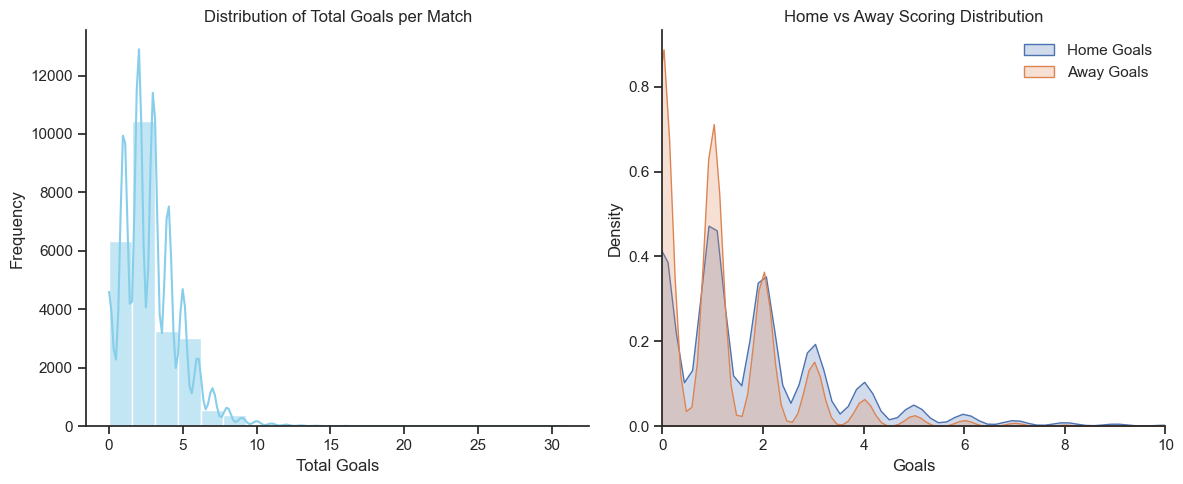

In [12]:
sns.set_theme(style="ticks") 

plt.figure(figsize=(12, 5))

# ---  Total Goals ---
plt.subplot(1, 2, 1)
sns.histplot(df_intl_results['home_score']+df_intl_results['away_score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Total Goals per Match')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
sns.despine() 

# ---  Home vs Away ---
plt.subplot(1, 2, 2)
sns.kdeplot(df_intl_results['home_score'], label='Home Goals', fill=True)
sns.kdeplot(df_intl_results['away_score'], label='Away Goals', fill=True)
plt.title('Home vs Away Scoring Distribution')
plt.xlabel('Goals')
plt.xlim(0, 10)
plt.legend(frameon=False) 
sns.despine() 

plt.tight_layout()
plt.show()


* The **Total Goals** distribution helps confirm if match outcomes follow a Poisson-like process, which is essential for the *Dixon-Coles* model.
* Comparing **Home vs. Away** scoring distributions allows us to quantify the historical "Home Advantage" present in international football.

## 4.2 Group-by-Group Performance Comparison (2026 Groups A-L)

In [13]:
# Create a dataframe of results by team
# Home results
home = df_intl_results[['home_team', 'home_score', 'away_score']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
)

# away resuts
away = df_intl_results[['away_team', 'away_score', 'home_score']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
)

# concat both dataframes
all_performances = pd.concat([home, away])

# set win, loss, draw values
all_performances['win'] = (all_performances['goals_for'] > all_performances['goals_against']).astype(int)
all_performances['loss'] = (all_performances['goals_for'] < all_performances['goals_against']).astype(int)
all_performances['draw'] = (all_performances['goals_for'] == all_performances['goals_against']).astype(int)

# aggregate stats by team
team_stats = all_performances.groupby('team').agg({
    'win': 'sum',
    'loss': 'sum',
    'draw': 'sum',
    'goals_for': 'sum',
    'goals_against': 'sum',
    'team': 'count' 
}).rename(columns={'team': 'total_matches'}).reset_index()

# filter the stats for WC2026 teams
df_final_stats = pd.merge(df_teams, team_stats, left_on='team_name', right_on='team', how='inner')


GROUP A STATISTICS
     team_name  win  loss  draw  goals_for  goals_against
        Mexico  268   104    98      932.0          430.0
  South Africa  124    60    88      365.0          239.0
   South Korea  190    71    93      671.0          306.0
Czech Republic  122    63    38      391.0          218.0


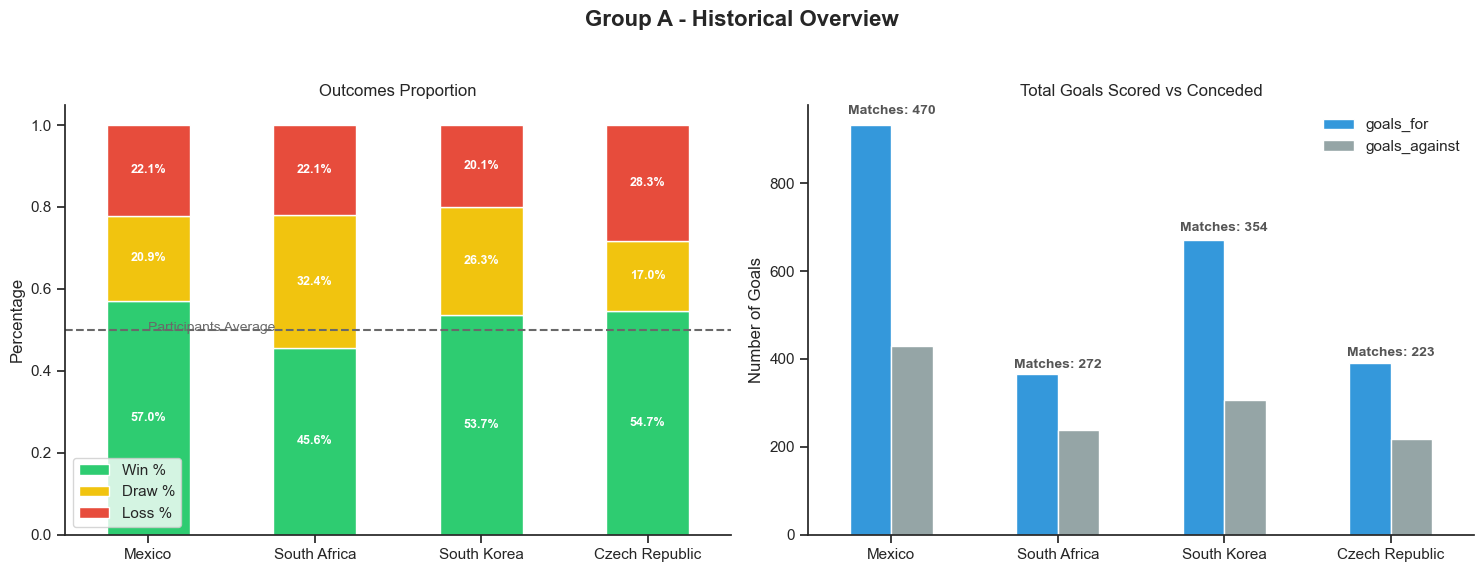


GROUP B STATISTICS
             team_name  win  loss  draw  goals_for  goals_against
                Canada  106    74    60      372.0          270.0
Bosnia and Herzegovina   70    70    37      269.0          247.0
                 Qatar  119    79    46      410.0          268.0
           Switzerland  146   105    93      543.0          425.0


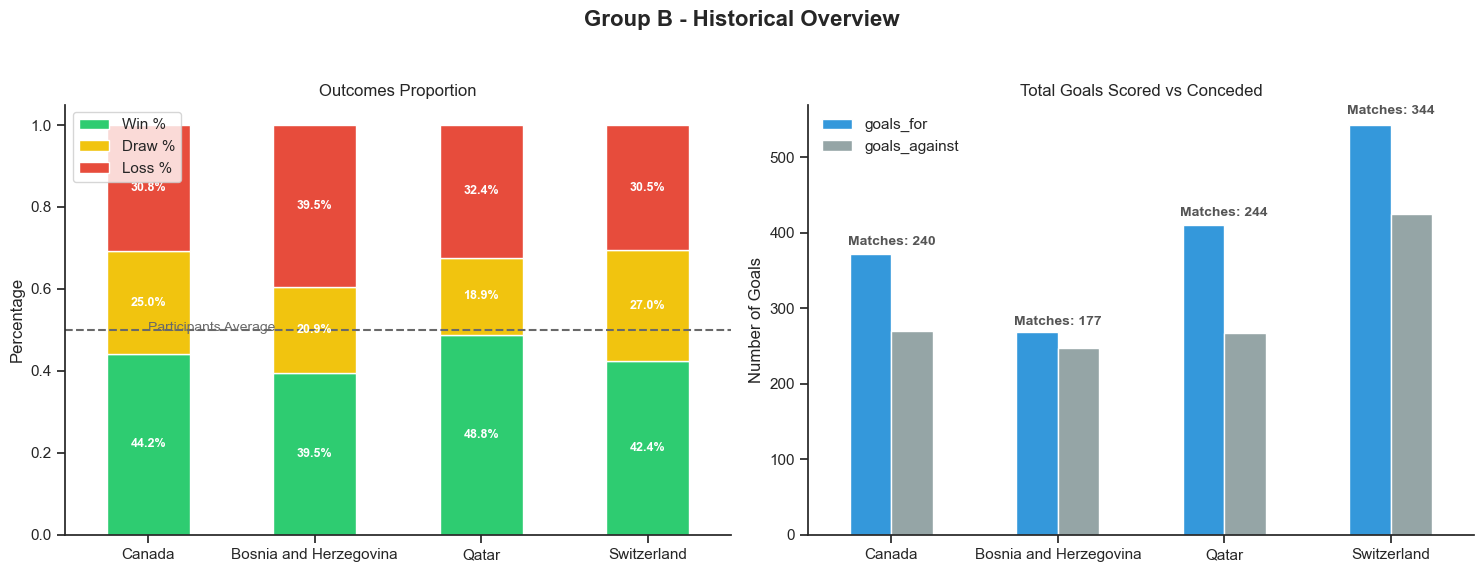


GROUP C STATISTICS
team_name  win  loss  draw  goals_for  goals_against
   Brazil  306    91   104     1075.0          443.0
  Morocco  168    73    94      501.0          242.0
    Haiti  142    94    56      544.0          366.0
 Scotland  150   101    71      471.0          366.0


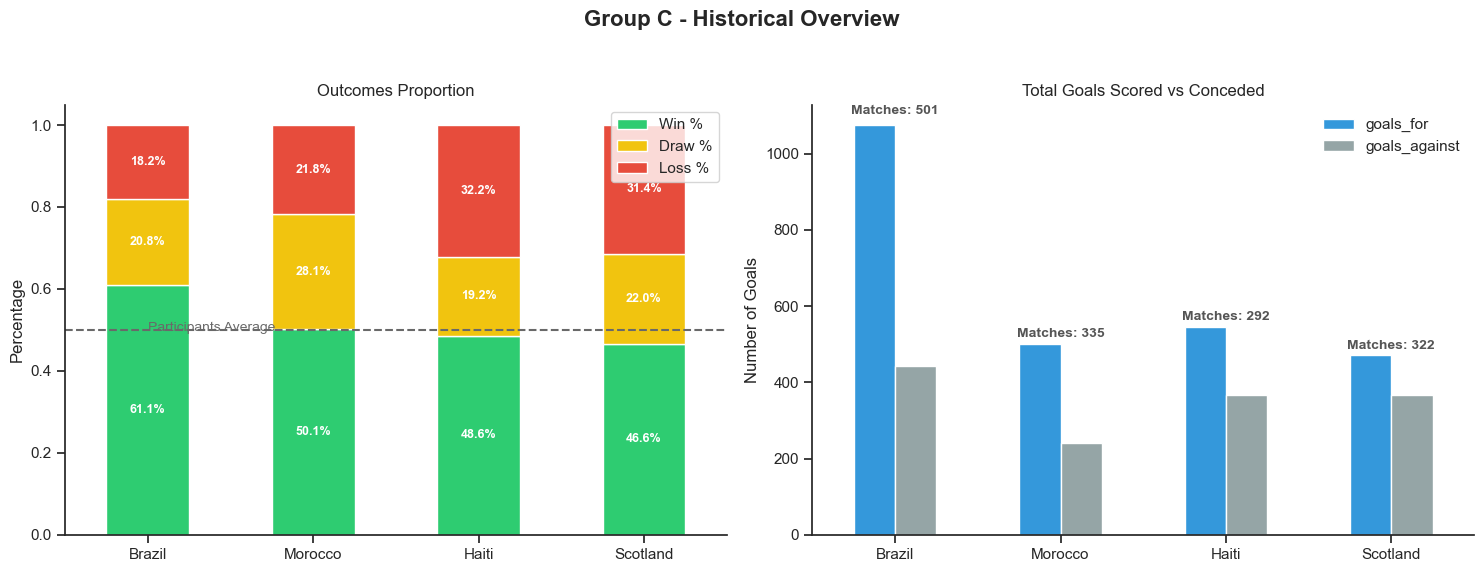


GROUP D STATISTICS
    team_name  win  loss  draw  goals_for  goals_against
United States  194   101    65      629.0          402.0
     Paraguay  148   152    99      529.0          577.0
    Australia  160    59    59      689.0          237.0
       Turkey  140   128    69      482.0          467.0


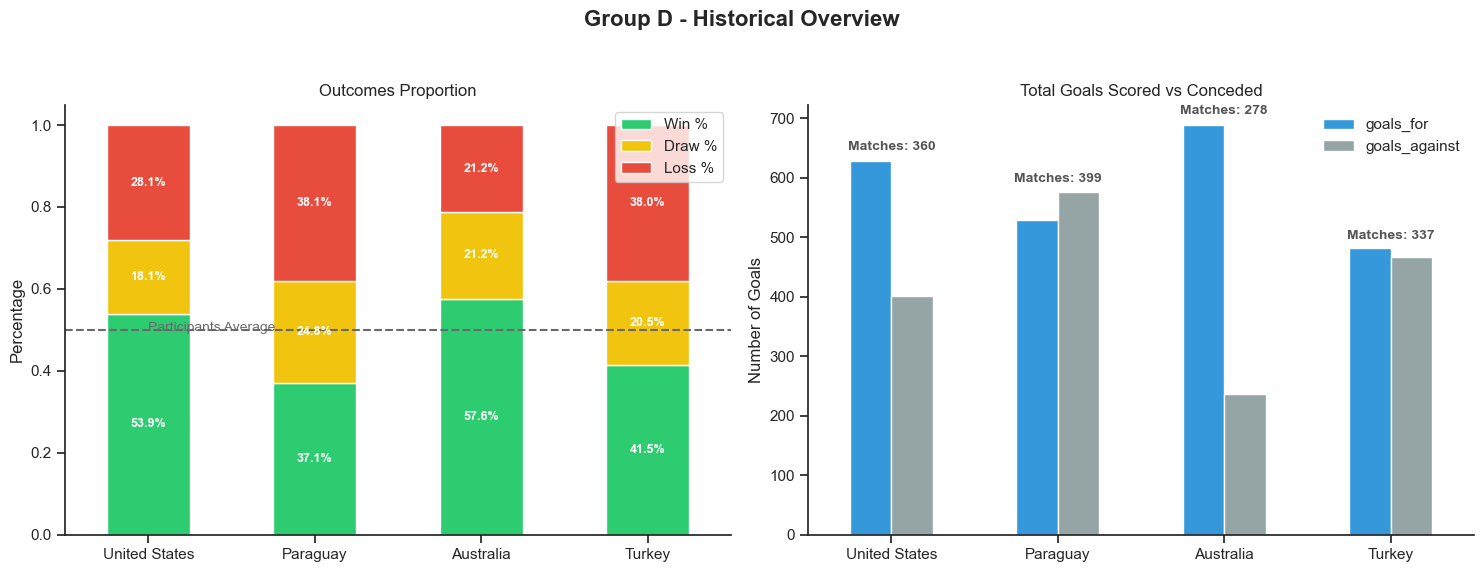


GROUP E STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
    Germany  278    60    87     1009.0          397.0
    Curaçao   74    97    62      350.0          385.0
Ivory Coast  189    73    88      612.0          321.0
    Ecuador   85   164    77      368.0          578.0


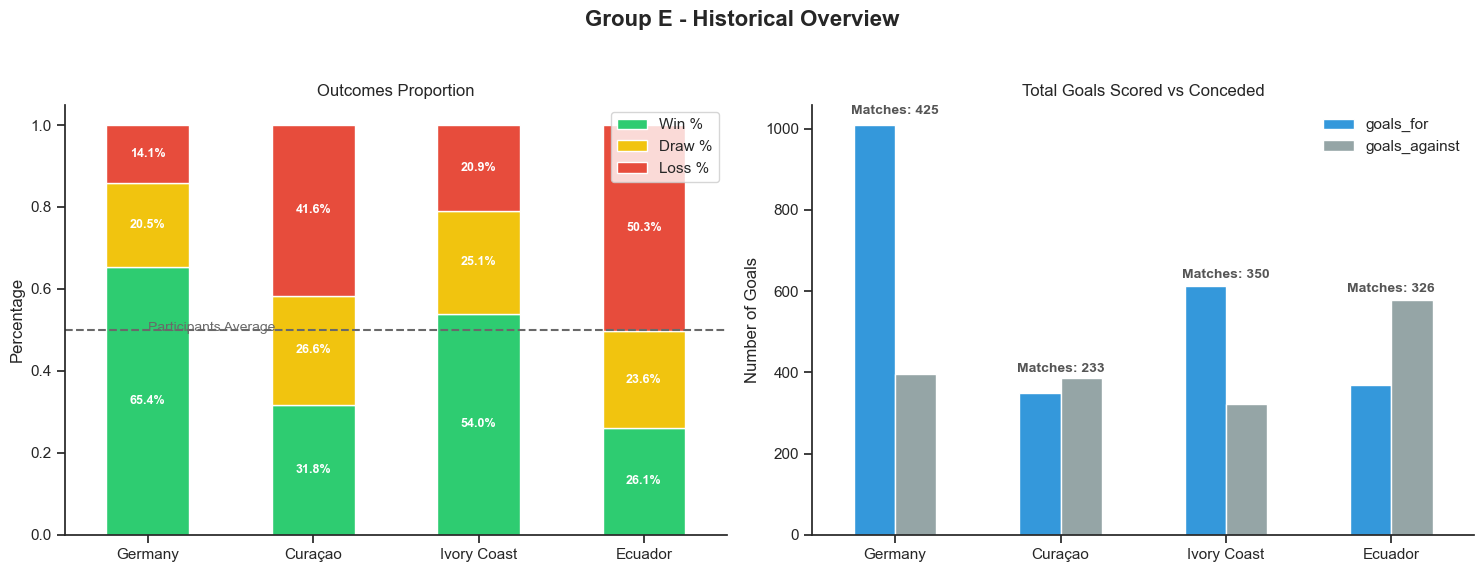


GROUP F STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
Netherlands  245    76    77      880.0          339.0
      Japan  170    71    63      613.0          258.0
     Sweden  187   108    73      647.0          399.0
    Tunisia  157    83    96      503.0          299.0


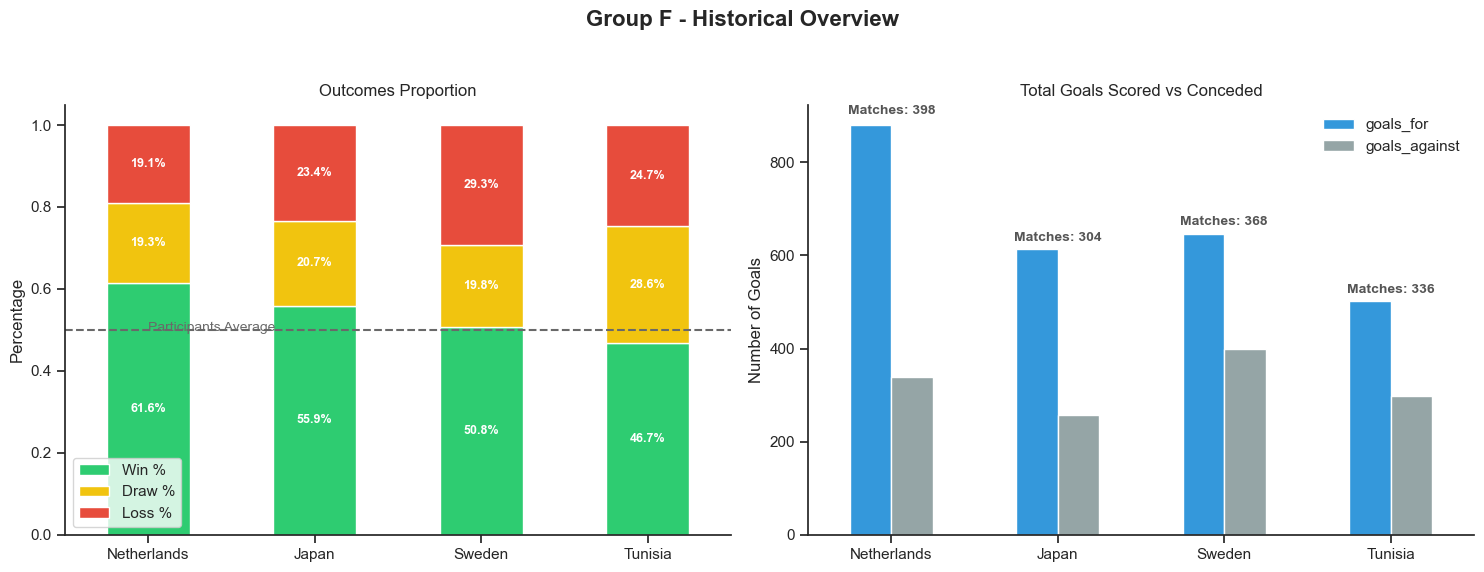


GROUP G STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
    Belgium  199   102    73      714.0          414.0
      Egypt  190    81    81      596.0          312.0
       Iran  208    45    78      710.0          226.0
New Zealand   85    45    23      355.0          170.0


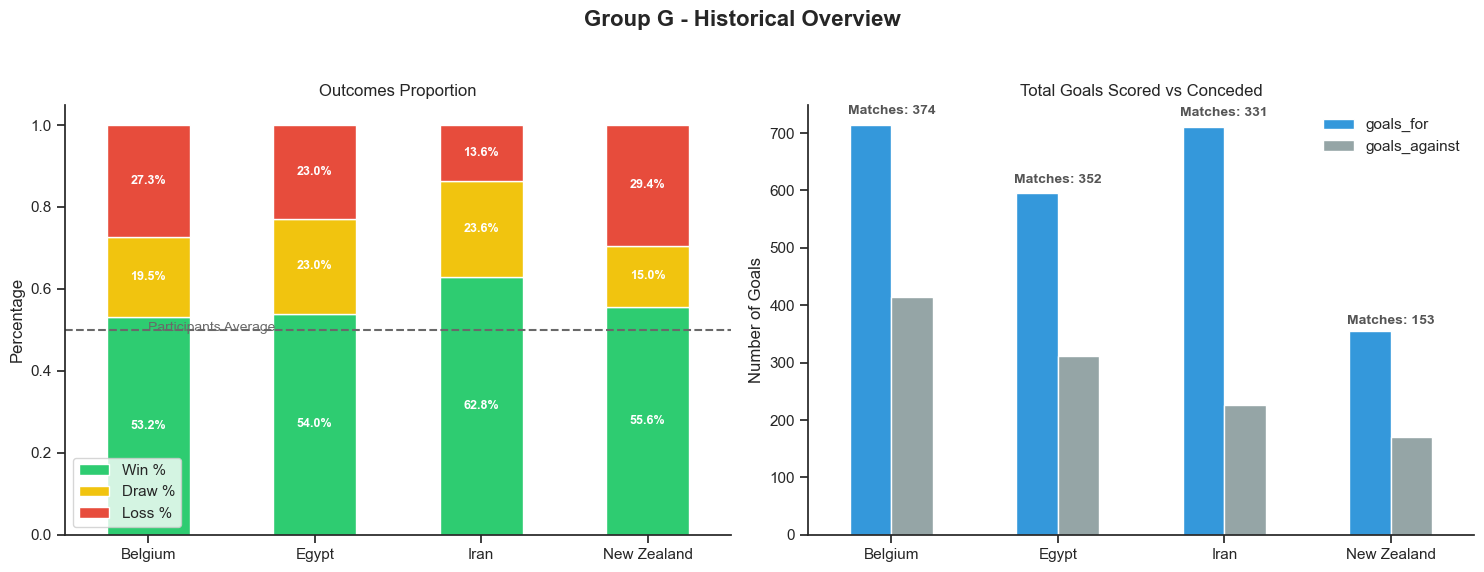


GROUP H STATISTICS
   team_name  win  loss  draw  goals_for  goals_against
       Spain  270    67    87      931.0          342.0
  Cape Verde   70    72    41      194.0          208.0
Saudi Arabia  148    71    62      496.0          268.0
     Uruguay  229   136   107      794.0          515.0


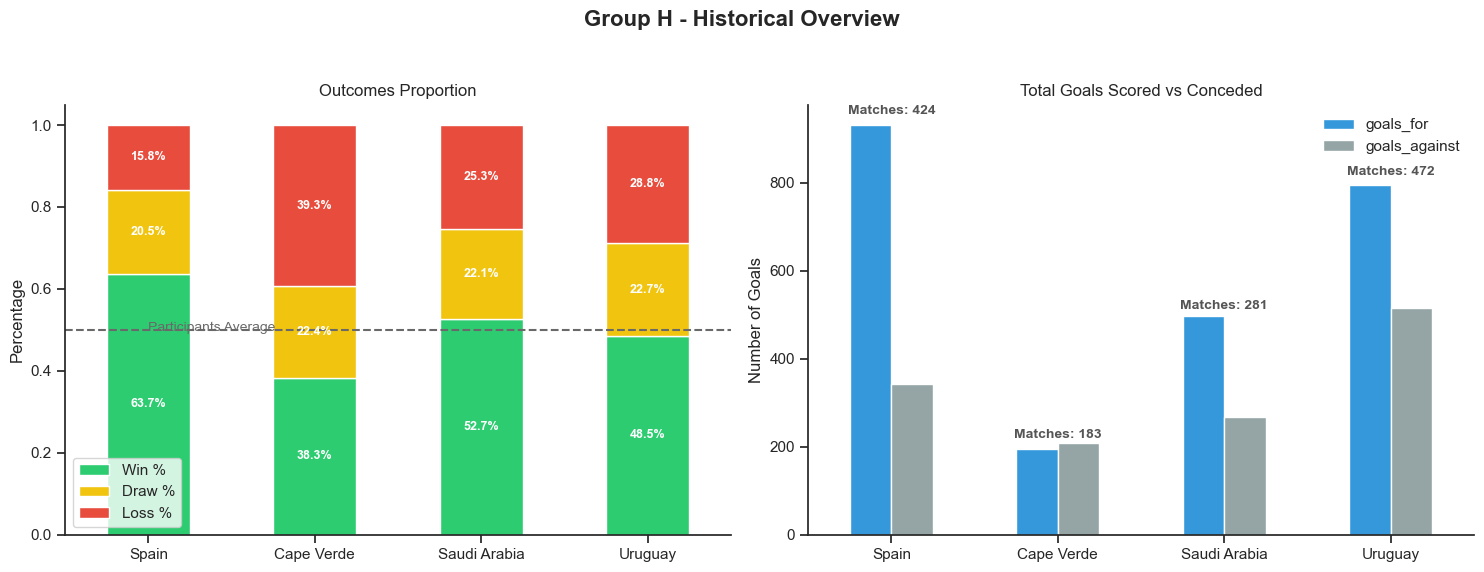


GROUP I STATISTICS
team_name  win  loss  draw  goals_for  goals_against
   France  237    80    89      791.0          364.0
  Senegal  190    82   100      553.0          297.0
     Iraq  126    69    60      424.0          237.0
   Norway  124   120    68      452.0          406.0


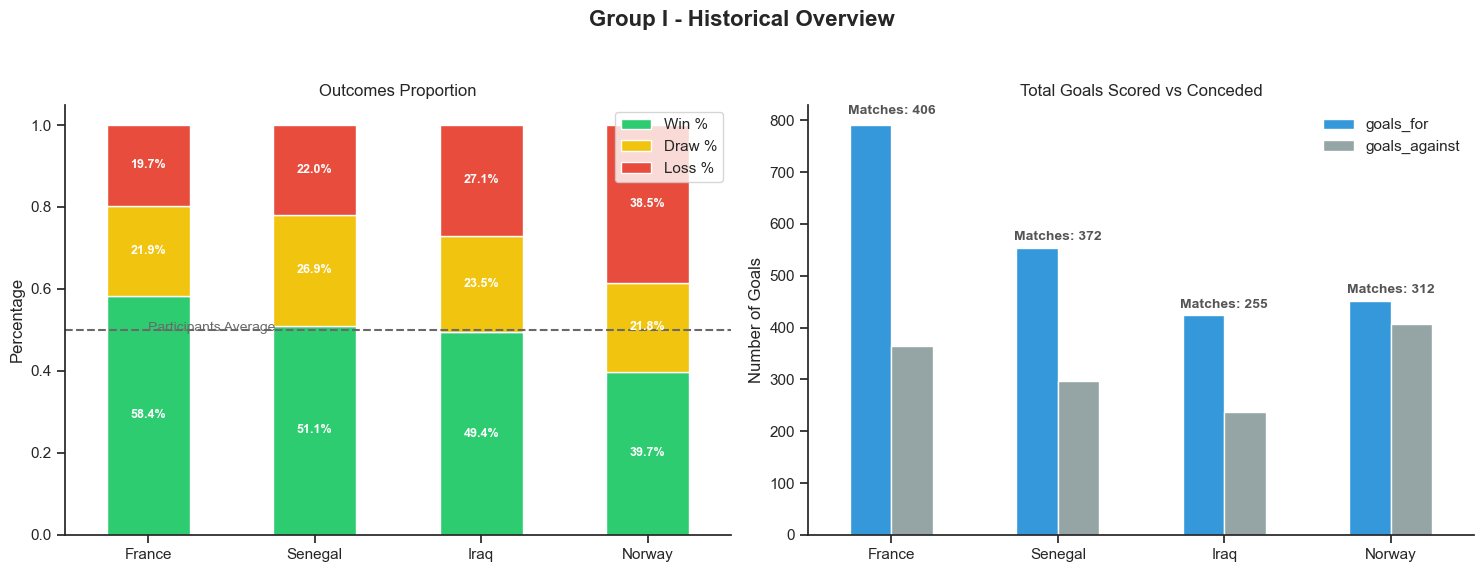


GROUP J STATISTICS
team_name  win  loss  draw  goals_for  goals_against
Argentina  283    88   109      954.0          444.0
  Algeria  161    86    84      534.0          331.0
  Austria  153   113    61      564.0          413.0
   Jordan   86    60    52      300.0          200.0


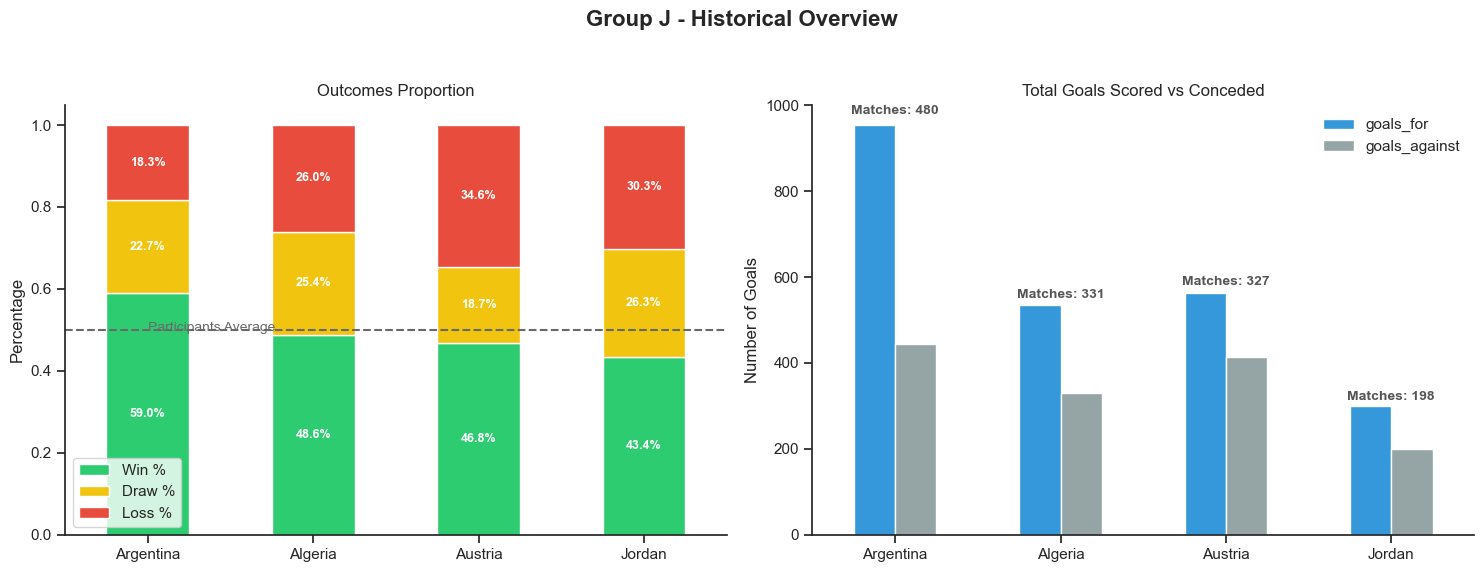


GROUP K STATISTICS
 team_name  win  loss  draw  goals_for  goals_against
  Portugal  221    82    89      741.0          369.0
  DR Congo  136    99    85      469.0          359.0
Uzbekistan  104    47    37      358.0          191.0
  Colombia  136   128    96      435.0          447.0


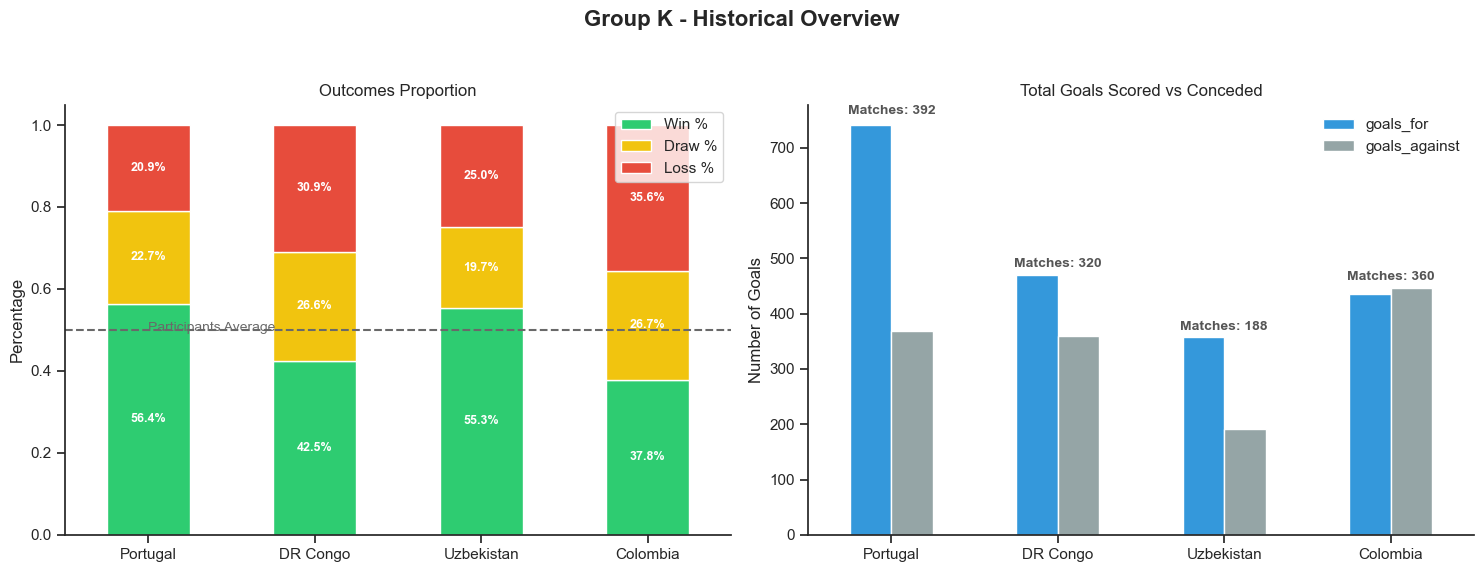


GROUP L STATISTICS
team_name  win  loss  draw  goals_for  goals_against
  England  224    60    96      787.0          265.0
  Croatia  133    48    60      418.0          218.0
    Ghana  176    81    85      527.0          290.0
   Panama  110   117    71      418.0          440.0


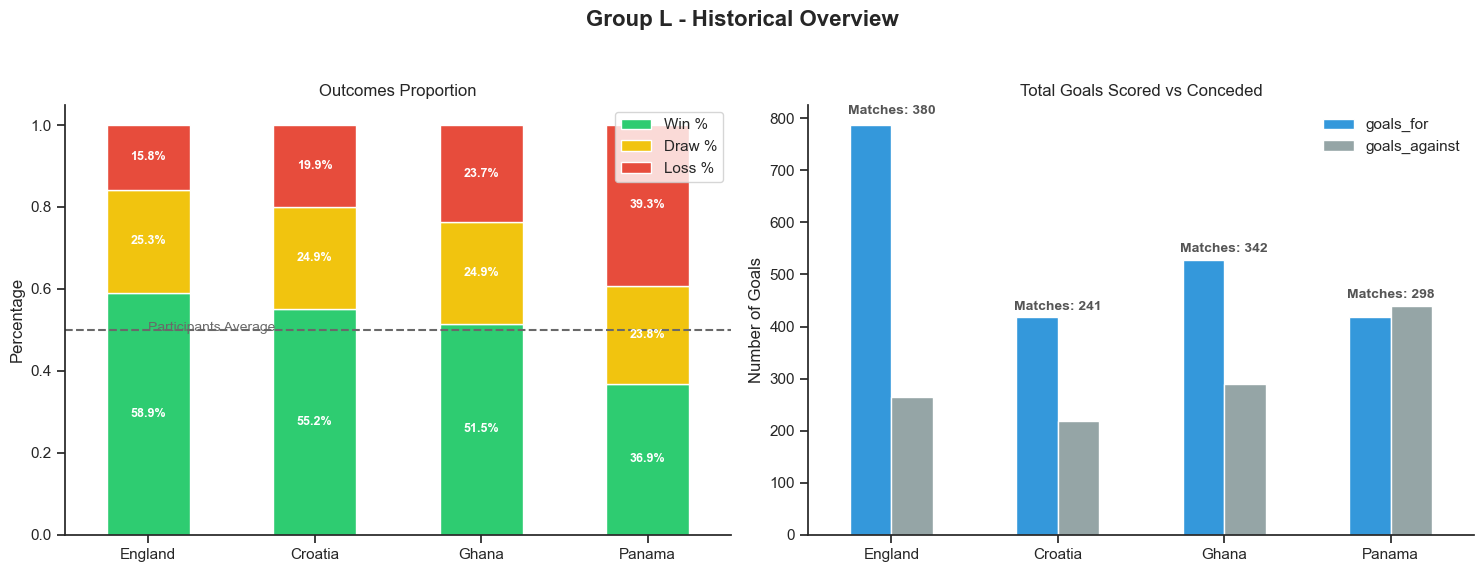

In [14]:
winlevel = (df_final_stats['win'] / df_final_stats['total_matches']).mean()

for g in sorted(df_final_stats['group_letter'].unique()):
    df_g = df_final_stats[df_final_stats['group_letter'] == g].copy()
    
    # Calculate ratios
    df_g['Win %'] = df_g['win'] / df_g['total_matches']
    df_g['Loss %'] = df_g['loss'] / df_g['total_matches']
    df_g['Draw %'] = df_g['draw'] / df_g['total_matches']

    print(f"\n{'='*30}\nGROUP {g} STATISTICS\n{'='*30}")
    print(df_g[['team_name', 'win', 'loss', 'draw', 'goals_for', 'goals_against']].to_string(index=False))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Group {g} - Historical Overview', fontsize=16, fontweight='bold')

    # --- Plot 1: Performance (Stacked Bar) ---
    ax = df_g.set_index('team_name')[['Win %', 'Draw %', 'Loss %']].plot(
        kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], ax=ax1
    )
    ax1.axhline(y=winlevel, color='dimgray', linestyle='--')
    ax1.text(x=0, y=0.49, s="Participants Average", color='dimgray', fontsize=10, va='bottom')
     
    ax1.set_title('Outcomes Proportion')
    ax1.set_ylabel('Percentage')
    ax1.set_xlabel('')
    
    # percentaje in the bar
    for p in ax1.patches:
        width, height = p.get_width(), p.get_height()
        if height > 0.05: 
            x, y = p.get_xy() 
            ax1.annotate(f'{height:.1%}', (x + width/2, y + height/2), 
                         ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # --- Plot 2: Goals (Scored vs Conceded) ---
    df_g.set_index('team_name')[['goals_for', 'goals_against']].plot(
        kind='bar', color=['#3498db', '#95a5a6'], ax=ax2
    )

    ax2.legend(frameon=False)
    ax2.set_title('Total Goals Scored vs Conceded')
    ax2.set_ylabel('Number of Goals')
    ax2.set_xlabel('')
    
    # Include total match above the columns
    for i, matches in enumerate(df_g['total_matches']):
        max_goal = max(df_g.iloc[i]['goals_for'], df_g.iloc[i]['goals_against'])
        ax2.text(i, max_goal + (max_goal * 0.02), f'Matches: {int(matches)}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#555555')

    
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='x', labelrotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## **Unit 5: Insights & Future Work**
### 5.1 Key Findings & Statistical Anomalies 

**Group A:**
Three of the participants have an above-average win percentage in official matches, which puts *South Africa* in a vulnerable position against three fairly evenly matched opponents. A victory for the African team in the first match could spice up the group.

**Group B:**
Four teams with very similar records and below the historical average. Canada (the weakest seeded team) can consider itself fortunate to have drawn only one superior opponent.

**Group C:**
In this group, the expected battle will be for second place, as *Brazil* appears far superior to the rest. The absence of a clear favorite in the group also makes it difficult to secure one of the best third-place finishes.

**Group D:**
*Australia* and the *United States* are expected to dominate. *Paraguay* appears to be the weakest in terms of record, with the added disadvantage of being one of the few teams that has conceded more goals than it has scored.

**Group E:**
As in Group D, there are clear dominant teams: *Germany* and *Ivory Coast*. Just like in Group D: the team with the weakest record is one of the few that conceded more goals than it scored: *Ecuador*... With one difference: *Ecuador* has a longer history in World Cups and belongs to a confederation with more established teams.

**Group F:**
Clearly, the *Netherlands* is the favorite, and the rest of the teams are fairly evenly matched.

**Group G:**
The only group whose top seed has a worse record than all its rivals, but probably no one would bet on it being the weakest team in its group.

**Group H:**
With *Spain* and *Saudi Arabia* having the best win rates and being the only ones with above-average win rates, one might think they are the strongest contenders in the group... but then there's *Uruguay*: two-time world champion.

**Group I:** The last runner-up, *France*, is the favorite in its group.

**Group J:**
*Argentina* has a history that positions it as the main contender in its group, not only because of victories, but also because it has a higher goal difference and has played significantly more matches than its groupmates.

**Group K:**
*Portugal* and *Uzbekistan* are considered contenders for the top spots. However, *Colombia* has the worst winning record in the group, despite having a more successful history than *Uzbekistan* and *DR Congo*.

**Group L:**
*England* is the group favorite: undisputed in terms of winning record, goals scored, and goal difference. Panama has the weakest record in the group.


* **The "Elite" Ratio:** Most top-seeded teams maintain a 2:1 ratio (goals scored vs. conceded). Outside the top seeds, only Australia, South Korea, Japan, and Iran exhibit this level of historical dominance.
* **Goal Differential Anomalies:** Very few qualified teams show a negative goal differential; these typically correlate with the lowest win rates in their groups. Ecuador and Curacao are the outliers here, sharing the same group with similar metrics.
* **The South American Parity (CONMEBOL):** Win rates for powerhouses like Uruguay, Colombia, and Ecuador appear lower than expected. Undoubtedly, further analysis is needed.

### 5.2 Next Steps: Exporting Clean Data for ML Modeling

In [15]:
#df_intl_results.to_csv('../data/processed/matches.csv', index=False)
df_intl_results.to_parquet('../data/processed/results.parquet')


In [16]:
df_intl_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False
2,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False
4,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True
